# 🐍 Python Level 1 - Introductory course
## Class 2 — Data Structures

**Python instructor - Alexandra Oliveira**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">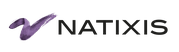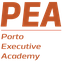</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | Lists |
| 2 | Tuples |
| 3 | Sets |
| 4 | Dictionaries |
| 5 | Handy extras — `enumerate`, `sorted`, `sum`, `min`, `max` |
| 6 | Choosing the right structure |
| 7 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Hold many values in a single variable
- Reach a value by its **name** instead of counting positions
- Pick the right structure for the job
- Read and update data that has structure inside it

---

> 💡 Last class every value had its own variable. That works for three values and falls apart
> at thirty. Today you learn the four containers Python gives you — and the last one,
> the **dictionary**, is the one you will use most for the rest of the course.

---
## 1. Lists

A **list** holds several values **in order**, in one variable. You write it with square
brackets and commas.

```
products = ["Coffee", "Tea", "Sugar"]
```

### Reaching an item — by position

Each item has a **position**, called its **index**. Python counts from **0**, not 1.

| `products` | `"Coffee"` | `"Tea"` | `"Sugar"` |
|------------|-----------|--------|----------|
| index | `0` | `1` | `2` |
| from the end | `-3` | `-2` | `-1` |

`products[0]` is the first item and `products[-1]` is the last — handy when you don't know how
long the list is.

### Slicing — taking a piece

`products[1:3]` means *"from index 1, up to but not including 3"*. The end is always excluded,
which feels odd for about a week and then feels normal.

In [ ]:
products = ["Coffee", "Tea", "Sugar", "Milk"]

print(products)              # the whole list
print(len(products))         # 4  - how many items

In [ ]:
print(products[0])           # Coffee - the first
print(products[-1])          # Milk   - the last

In [ ]:
print(products[1:3])         # ['Tea', 'Sugar'] - index 1 and 2, not 3

In [ ]:
print(products[:2])          # ['Coffee', 'Tea'] - from the start

In [ ]:
print(products[2:])          # ['Sugar', 'Milk'] - to the end

### Changing a list

A list is **changeable**: you can add, replace and remove items after creating it.

| What you want | How |
|---------------|-----|
| Add to the end | `products.append("Salt")` |
| Replace an item | `products[1] = "Green tea"` |
| Remove by value | `products.remove("Sugar")` |
| Remove by position | `products.pop(0)` — and it hands the item back |
| Is it in there? | `"Tea" in products` |
| How many times? | `products.count("Tea")` |

> ⚠️ `.remove()` takes the **value**, `.pop()` takes the **position**. Mixing them up is a
> common slip.

In [ ]:
products = ["Coffee", "Tea", "Sugar"]

products.append("Milk")          # add to the end
print(products)

In [ ]:
products[1] = "Green tea"        # replace the item at index 1
print(products)

In [ ]:
products.remove("Sugar")         # remove by value
print(products)

In [ ]:
removed = products.pop(0)        # remove by position, and keep what came out
print(removed, "->", products)

In [ ]:
print("Milk" in products)        # True
print(products.count("Milk"))    # 1

---
## 2. Tuples

A **tuple** is a list that **cannot be changed** after you create it. Round brackets instead
of square ones.

```
price_range = (5.00, 50.00)
```

You read it exactly like a list — `price_range[0]` — but there is no `.append()`, no
replacing, no removing. Trying to change it is an error.

**Why would you want that?** Because "cannot change" is sometimes precisely what you need: a
pair of values that belong together, a fixed set of options, a row of data you don't want
anything to overwrite by accident. If a value should never move, a tuple says so.

In [ ]:
price_range = (5.00, 50.00)      # a lowest and a highest price, fixed

print(price_range)
print(price_range[0])            # 5.0  - read it like a list
print(len(price_range))          # 2

In [ ]:
lowest = price_range[0]
highest = price_range[1]
print(f"Prices run from {lowest:.2f} to {highest:.2f} EUR")

# price_range[0] = 1.00   <- this would be an error: a tuple cannot be changed

---
## 3. Sets

A **set** holds only **unique** values, and keeps **no order**. Curly brackets.

Give it duplicates and they simply vanish — which is the whole point. If your question is
*"which different cities did we deliver to?"*, a set answers it in one line.

| What you want | How |
|---------------|-----|
| Remove duplicates | `set(my_list)` |
| Add a value | `cities.add("Braga")` |
| Remove a value | `cities.discard("Faro")` |
| Is it in there? | `"Porto" in cities` |

And because a set knows nothing about order, it can compare itself to another set:

| Question | How | Reads as |
|----------|-----|----------|
| In either one? | `a.union(b)` | everything, once |
| In both? | `a.intersection(b)` | the overlap |
| In `a` but not `b`? | `a.difference(b)` | what only `a` has |

In [ ]:
deliveries = ["Porto", "Lisbon", "Porto", "Faro", "Lisbon"]

cities = set(deliveries)         # duplicates disappear
print(cities)
print(len(cities))               # 3 - three different cities

In [ ]:
cities.add("Braga")
cities.discard("Faro")           # .discard() is safe even if it isn't there
print("Porto" in cities)         # True

In [ ]:
# Comparing two sets
monday = {"Porto", "Lisbon"}
tuesday = {"Lisbon", "Braga"}

print(monday.union(tuesday))          # every city across both days
print(monday.intersection(tuesday))   # {'Lisbon'} - delivered to on both days
print(monday.difference(tuesday))     # {'Porto'}  - Monday only

---
## 4. Dictionaries

This is the important one.

A **dictionary** stores each value under a **name you choose**, called a **key**. Instead of
remembering that position 2 is the city, you just ask for `"city"`.

```
customer = {"name": "Ana Silva", "city": "Porto", "orders": 3}
```

Every entry is a **key: value** pair. You reach a value with square brackets and its key:
`customer["city"]`.

| What you want | How |
|---------------|-----|
| Read a value | `customer["city"]` |
| Read safely | `customer.get("phone", "unknown")` — no error if the key is missing |
| Add or update | `customer["city"] = "Lisbon"` |
| Remove | `customer.pop("orders")` |
| Is that key there? | `"city" in customer` |

> ⚠️ `customer["phone"]` on a key that does not exist **stops your program**. `.get()` returns
> your fallback instead. Use `.get()` whenever you are not certain the key is there.

In [ ]:
customer = {"name": "Ana Silva", "city": "Porto", "orders": 3}

print(customer)
print(customer["name"])                    # Ana Silva - by name, not by position
print(customer.get("phone", "unknown"))    # unknown - the key isn't there, no error

In [ ]:
customer["city"] = "Lisbon"                # update an existing key
customer["email"] = "ana@example.com"      # a new key is simply added
print(customer)

In [ ]:
customer.pop("orders")                     # remove a key
print("orders" in customer)                # False
print(len(customer))                       # 3 - how many pairs

### Going through a dictionary

`.keys()` gives the names, `.values()` gives the values, and `.items()` gives **both at once**
— which is what you want almost every time.

### Structures inside structures

A value in a dictionary can itself be a list or another dictionary. That is how real data is
shaped:

```
   customer                    (a dict)
   ├── "name"   ──▶ "Ana Silva"      (a str)
   ├── "city"   ──▶ "Porto"          (a str)
   └── "orders" ──▶ [24.00, 15.50]   (a list inside it)
```

To reach one order you name the key, then the position: `customer["orders"][0]`. Read it left
to right — *"in customer, the orders, the first one"*.

In [ ]:
customer = {"name": "Ana Silva", "city": "Porto", "orders": [24.00, 15.50, 40.00]}

# .items() gives the key and the value together
for key, value in customer.items():
    print(f"{key}: {value}")

print()
print(list(customer.keys()))      # ['name', 'city', 'orders']

In [ ]:
# A list inside a dictionary
print(customer["orders"])         # the whole list
print(customer["orders"][0])      # 24.0 - the first order
print(len(customer["orders"]))    # 3    - how many orders

---
## 5. Handy extras — `enumerate`, `sorted`, `sum`, `min`, `max`

These are **built-in functions**. "Built-in" means they come with Python itself: nothing to
install, nothing to import, always just there. You have used four already — `print()`,
`len()`, `int()` and `range()`.

It is worth knowing the word, because it tells you how something is written:

| | How you write it | Example |
|---|------------------|---------|
| **Built-in function** | the value goes **inside the brackets** | `len(prices)` |
| **Method** | attached to a value with a **dot** | `prices.append(9.99)` |

A method belongs to one kind of value — `.append()` only makes sense on a list. A built-in
is general: `len()` works on a list, a string, a set and a dict alike.

| Helper | What it gives you |
|--------|-------------------|
| `enumerate(my_list)` | each item **and its position**, so you can number your output |
| `sorted(my_list)` | a **new** list in order — the original is untouched |
| `sum(numbers)` | the total |
| `min(numbers)` / `max(numbers)` | the smallest / largest |

### Sorting: `sorted()` or `.sort()`

Both put a list in order. One is a built-in and one is a list method — and that is the whole
difference between them:

| | Does what | Gives back |
|---|-----------|------------|
| `sorted(prices)` | builds a **new** sorted list, leaves `prices` alone | the sorted list |
| `prices.sort()` | rearranges **`prices` itself** | `None` |

**So why use `.sort()` at all, if it gives back nothing?** Because usually you do not want a
copy — you want the list itself to be in order from here on. One list, sorted once, used in
order everywhere after. A copy would leave you with two lists to keep track of.

One question decides it: **do I still need the original order?**

- **Yes** → `sorted()`, and you keep both
- **No** → `.sort()`, and the list is simply in order now

> ⚠️ Never write `prices = prices.sort()`. It gives back `None`, so that line throws your list
> away and leaves you holding nothing. Write `prices.sort()` on its own line.

In [ ]:
prices = [8.50, 2.10, 4.20]

# enumerate() - the position and the item together
for position, price in enumerate(prices):
    print(f"{position + 1}. {price:.2f} EUR")

In [ ]:
print(sum(prices))               # 14.8
print(min(prices), max(prices))  # 2.1 8.5
print(round(sum(prices) / len(prices), 2))   # 4.93 - the average

In [ ]:
# sorted() - a sorted COPY. The original list is left alone.
print(sorted(prices))            # [2.1, 4.2, 8.5]
print(prices)                    # [8.5, 2.1, 4.2] - untouched

In [ ]:
# .sort() - changes the list ITSELF, and hands back nothing
print(prices.sort())             # None  <- this is why you never assign it
print(prices)                    # [2.1, 4.2, 8.5] - prices is sorted from now on

---
## 6. Choosing the right structure

Four containers, and the choice is almost always obvious once you ask the right question:

```
        Do the values need names?
                  │
          Yes ────┴──── No
           │             │
           ▼             ▼
         dict     Must they stay fixed?
                          │
                  Yes ────┴──── No
                   │             │
                   ▼             ▼
                 tuple    Only unique ones?
                                  │
                          Yes ────┴──── No
                           │             │
                           ▼             ▼
                          set          list
```

| Structure | Written | Use it when | Example |
|-----------|---------|-------------|---------|
| `list` | `[ ]` | order matters, duplicates fine | the day's orders, in order |
| `tuple` | `( )` | the values must not change | a lowest/highest price pair |
| `set` | `{ }` | you only want unique values | which cities we delivered to |
| `dict` | `{key: value}` | each value needs a name | one customer's details |

> 💡 In doubt, use a **list** for many of the same thing and a **dict** for one thing with
> several named parts. A list of dicts — many things, each with named parts — is the single
> most common shape in real data, and it is exactly what a spreadsheet is. You will meet it
> again as a `pandas` DataFrame next class.

---
## 7. 🔗 Putting it all together — order register

All four structures in one program.

### The situation

You have today's **orders**. Each one records who placed it, which city it goes to, and its
total. The same customer can order more than once. You want a short report: what each customer
spent in total, how many orders they placed, which cities are involved, and who spent the most.

### What the program must do

1. Start from a **list of orders**, where each order is a **dict** with named fields
2. Build a new dict of **customer → list of their order totals**, and a **set** of the cities
3. Total each customer's orders with `sum()`
4. Print a numbered line per customer, using `enumerate()`
5. Print how many customers, the cities in order, and the overall total
6. Find the **top customer** by keeping track of the biggest total as you go

### Where each concept appears

| Concept from today | Where it is used |
|--------------------|------------------|
| `list` | the orders, and each customer's totals |
| `dict` | each order, and the register we build |
| `set` | collecting each city once |
| `.append()` | adding a total to a customer's list |
| `in` | checking whether we have seen a customer yet |
| `.items()` | going through the register |
| `enumerate()` | numbering the report |
| `sum()`, `len()`, `sorted()` | the totals and the tidy city list |
| `if` / `else`, `for` | from Class 1 |

In [ ]:
# ── Today's orders: a list of dicts, each with named fields ────────────────
orders = [
    {"customer": "Ana Silva",   "city": "Porto",  "total": 24.00},
    {"customer": "Bruno Costa", "city": "Lisbon", "total": 15.50},
    {"customer": "Ana Silva",   "city": "Porto",  "total": 40.00},
    {"customer": "Clara Dias",  "city": "Faro",   "total":  8.75},
    {"customer": "Bruno Costa", "city": "Lisbon", "total": 12.25},
]

# ── Step 1: group each customer's totals, and collect the cities ───────────
register = {}        # customer name -> list of their order totals
cities = set()       # each city, once

for order in orders:
    name = order["customer"]
    if name in register:
        register[name].append(order["total"])
    else:
        register[name] = [order["total"]]
    cities.add(order["city"])

# ── Step 2: the report, one numbered line per customer ─────────────────────
print("ORDER REGISTER")
print("-" * 44)

for position, name in enumerate(register):
    totals = register[name]
    print(f"{position + 1}. {name:<14}{sum(totals):>8.2f} EUR  (orders: {len(totals)})")

# ── Step 3: the summary ────────────────────────────────────────────────────
grand_total = 0
for name in register:
    grand_total += sum(register[name])

print("-" * 44)
print(f"Customers   : {len(register)}")
print(f"Cities      : {sorted(cities)}")
print(f"Grand total : {grand_total:.2f} EUR")

# ── Step 4: the top customer - keep the biggest as we go ───────────────────
top_name = ""
top_total = 0
for name, totals in register.items():
    if sum(totals) > top_total:
        top_total = sum(totals)
        top_name = name

print(f"Top customer: {top_name} ({top_total:.2f} EUR)")

---

### 🎉 That's Level 1 Class 2!

| Concept | Key syntax |
|---------|-----------|
| List | `["Coffee", "Tea"]` |
| Item by position | `products[0]`, `products[-1]` |
| Slice | `products[1:3]` |
| Change a list | `.append()`, `.remove()`, `.pop()`, `products[1] = ...` |
| Count a value | `products.count("Tea")` |
| Tuple — cannot change | `(5.00, 50.00)` |
| Set — unique, no order | `set(my_list)`, `.add()`, `.discard()` |
| Compare sets | `.union()`, `.intersection()`, `.difference()` |
| Dictionary | `{"city": "Porto"}` |
| Value by key | `customer["city"]` |
| Safe read | `customer.get("phone", "unknown")` |
| Add / update / remove | `customer["x"] = 1`, `.pop("x")` |
| Go through a dict | `.keys()`, `.values()`, `.items()` |
| Inside a structure | `customer["orders"][0]` |
| Position while looping | `enumerate(my_list)` |
| Sort | `sorted(my_list)`, `my_list.sort()` |
| Totals | `sum()`, `min()`, `max()`, `len()` |

**The shape to remember:** a **list of dicts** — many things, each with named parts. It is what
a spreadsheet is, and next class you will load one straight from a file with `pandas`.

➡️ Now open the **exercises notebook**.